In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import re

In [12]:
# Path to the main folder
main_folder_path = '/Users/laurabreimann/Desktop/microtubule_data'

# Function to get the size of the specified files in a folder
def get_total_size_of_files(folder_path, file_extensions):
    total_size = 0
    for file in os.listdir(folder_path):
        if any(file.endswith(ext) for ext in file_extensions):
            total_size += os.path.getsize(os.path.join(folder_path, file))
    return total_size

# Define file extensions to look for
file_extensions = ['.mp4', '.npz']

# Original file size
original_file_size = 41360118  # in bytes

def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]


In [13]:
# Collecting data
folder_sizes = {'Original': original_file_size}
for folder in os.listdir(main_folder_path):
    folder_path = os.path.join(main_folder_path, folder)
    if os.path.isdir(folder_path):
        total_size = get_total_size_of_files(folder_path, file_extensions)
        folder_sizes[folder] = total_size

In [14]:
# Calculate each folder size as a percentage of the original
original_size = folder_sizes['Original']
folder_percentages = {name: (size / original_size) * 100 for name, size in folder_sizes.items()}


In [15]:

# Extracting 'k' values and levels from folder names
k_values = sorted(set(int(re.search('_k(\d+)_', name).group(1)) for name in folder_sizes if 'Original' not in name))
levels = sorted(set(int(re.search('_lev(\d+)', name).group(1)) for name in folder_sizes if 'Original' not in name))

# Sort the folder names in natural order by their 'k' value
sorted_folder_names = sorted(folder_percentages, key=natural_sort_key)

# Assign colors based on 'k' values and levels
k_colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))  # Different colors for different 'k' values
level_shades = np.linspace(0.5, 1, len(levels))  # Different shades for different levels


In [16]:
# Define a function to clean up folder names for the x-axis labels
def clean_folder_name(name):
    if 'Original' in name:
        return 'Original'
    # Remove 'sparz_k' and '_lev' from the folder name and replace with 'rt' and 'lev' respectively
    new_name = name.replace('sparz_k', '').replace('_lev', ' lev')
    # Extract only the 'rt' and level part of the name
    new_name = re.sub(r'^\d+_rt', 'rt', new_name)
    return new_name


# Calculate spacing between 'k' sections by introducing a dummy space in the x-axis labels
last_k_value = 0
spaced_folder_names = []
for folder_name in sorted_folder_names:
    if 'Original' not in folder_name:
        current_k_value = int(re.search('_k(\d+)_', folder_name).group(1))
        # # If the 'k' value changes, add a dummy space for spacing
        # if current_k_value != last_k_value and last_k_value != 0:
        #     spaced_folder_names.append('')  # Adding a space between different 'k' sections
        last_k_value = current_k_value
    cleaned_name = clean_folder_name(folder_name)
    spaced_folder_names.append(cleaned_name)

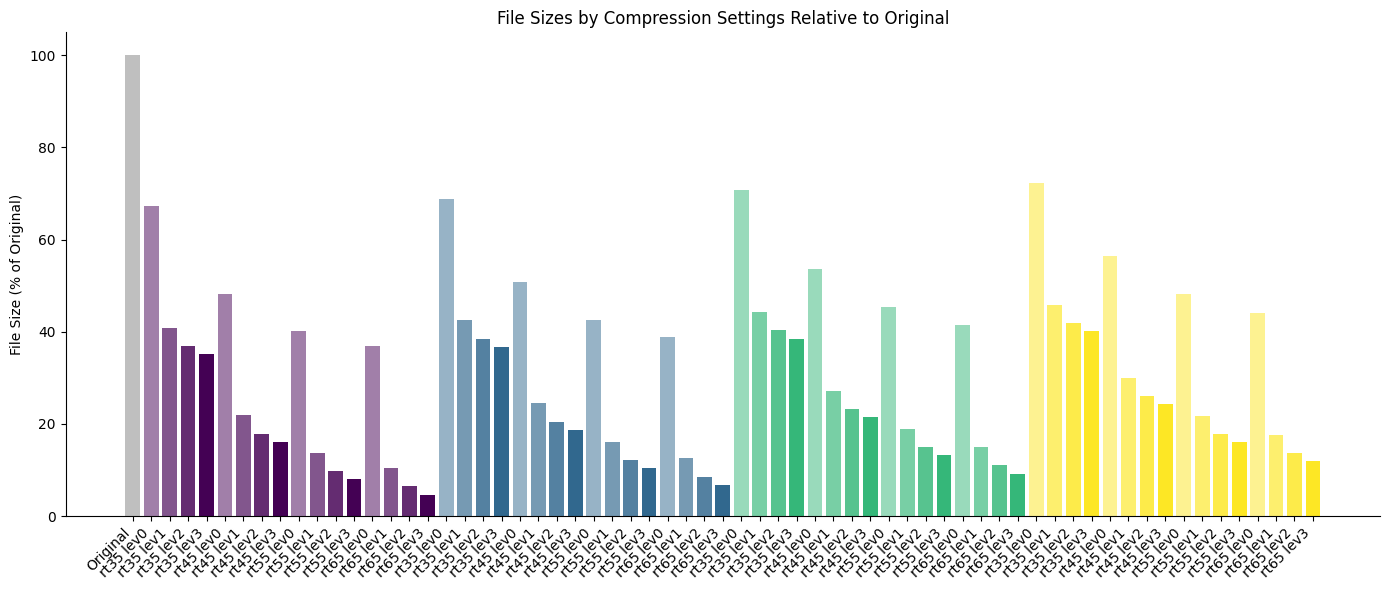

In [17]:
# Initialize the plot again without the gray bars over the 'rt' areas
fig, ax = plt.subplots(figsize=(14, 6))

# Plot each bar with the new label formatting and spacing
for i, folder_name in enumerate(sorted_folder_names):
    # Original bar in gray and set to 100%
    if 'Original' in folder_name:
        ax.bar(i, 100, color='gray', alpha=0.5)  # 100% for original
    else:
        # Find the 'k' value and level for the folder
        k_value = int(re.search('_k(\d+)_', folder_name).group(1))
        level = int(re.search('_lev(\d+)', folder_name).group(1))
        # Find the color and shade for the bar
        color = k_colors[k_values.index(k_value)]
        shade = level_shades[level]
        ax.bar(i, folder_percentages[folder_name], color=color, alpha=shade)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the x-axis labels to the cleaned and spaced names, rotate them for better readability
ax.set_xticks(np.arange(len(spaced_folder_names)))
ax.set_xticklabels(spaced_folder_names, rotation=45, ha="right")

# Set labels and title
#ax.set_xlabel('Settings')
ax.set_ylabel('File Size (% of Original)')
ax.set_title('File Sizes by Compression Settings Relative to Original')

# Use tight layout to ensure everything fits without overlapping
plt.tight_layout()
plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/file_sizes_240205.pdf', format='pdf')  
# Show the plot
plt.show()
